# Daten einlesen und vorbereiten

In [3]:
import pandas as pd

path_processed_data = '../Data/Processed/'
time_series_holidays = pd.read_csv(path_processed_data + 'timeseries_holidays.csv')

# Format der Spalte Datum richten
time_series_holidays['date'] = pd.to_datetime(time_series_holidays['date'])

time_series_holidays.head()

,Unnamed: 0,date,unit_sales,national_holiday,day_type,day_category
0,0,2013-01-02,582.0,no,weekday,weekday
1,1,2013-01-03,310.0,no,weekday,weekday
2,2,2013-01-04,338.0,no,weekday,weekday
3,3,2013-01-05,654.0,yes!,weekend,holiday (weekend)
4,4,2013-01-06,979.0,no,weekend,weekend


# Feature Engineering

In [4]:
time_series_added_features = time_series_holidays.copy()

print(time_series_added_features["national_holiday"].unique())
print()
print(time_series_added_features["day_type"].unique())
print()
print(time_series_added_features["day_category"].unique())

<StringArray>
['no', 'yes!']
Length: 2, dtype: str

<StringArray>
['weekday', 'weekend']
Length: 2, dtype: str

<StringArray>
['weekday', 'holiday (weekend)', 'weekend', 'holiday (weekday)']
Length: 4, dtype: str


In [5]:
# Bestehende Säulen ändern
# (a) Statt day_type (weekend or weekday) hat man lieber Nullen und Einsen -> neue Säule "is_weekday" erstellen und "day_type" löschen
time_series_added_features['is_weekday'] = (time_series_added_features['day_type'] == 'weekday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_type')

# (b) Ich weiß ob Wochenende ist oder nicht durch (a). Nun will ich wissen ob Holiday ist oder nicht. Ich brauche nicht beides zusammen in einer Säule -> werfe Säule "day_category" raus
time_series_added_features['is_holiday'] = time_series_added_features['day_category'].str.contains('holiday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_category')

# (c) Säule "national_holiday" überflüssig, da alle holidays = national holidays
time_series_added_features = time_series_added_features.drop(columns='national_holiday')

time_series_added_features.head(4)

,Unnamed: 0,date,unit_sales,is_weekday,is_holiday
0,0,2013-01-02,582.0,1,0
1,1,2013-01-03,310.0,1,0
2,2,2013-01-04,338.0,1,0
3,3,2013-01-05,654.0,0,1


In [6]:
# (1) Zeitbasierte Features
time_series_added_features['dayofweek']    = time_series_added_features['date'].dt.dayofweek
time_series_added_features['dayofmonth']   = time_series_added_features['date'].dt.day
time_series_added_features['dayofyear']    = time_series_added_features['date'].dt.dayofyear
time_series_added_features['weekofyear']   = time_series_added_features['date'].dt.isocalendar().week.astype(int)
time_series_added_features['month']        = time_series_added_features['date'].dt.month
time_series_added_features['quarter']      = time_series_added_features['date'].dt.quarter  # quarter teilt das Jahr in 4 Abschnitte
time_series_added_features['is_weekend']   = time_series_added_features['date'].dt.dayofweek >= 5

# (2) Lag Features
time_series_added_features['lag_7']  = time_series_added_features['unit_sales'].shift(7)
time_series_added_features['lag_14'] = time_series_added_features['unit_sales'].shift(14)
time_series_added_features['lag_21'] = time_series_added_features['unit_sales'].shift(21)
time_series_added_features['lag_28'] = time_series_added_features['unit_sales'].shift(28)

# (3) Rolling Features
# (3a) Rolling Mean
## Bsp: Rolling Mean 7 mit Shift 1 beantwortet die Frage: Wie viel wurde im Mittel in den letzten 7 Tagen bis inkl. gestern verkauft?
time_series_added_features['rolling_mean_7']  = time_series_added_features['unit_sales'].shift(1).rolling(7).mean()
time_series_added_features['rolling_mean_14'] = time_series_added_features['unit_sales'].shift(1).rolling(14).mean()
time_series_added_features['rolling_mean_21'] = time_series_added_features['unit_sales'].shift(1).rolling(21).mean()
time_series_added_features['rolling_mean_28'] = time_series_added_features['unit_sales'].shift(1).rolling(28).mean()

# (3b) Rolling Std
time_series_added_features['rolling_std_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).std()
time_series_added_features['rolling_std_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).std()
time_series_added_features['rolling_std_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).std()
time_series_added_features['rolling_std_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).std()

# (3c) Rolling Max
time_series_added_features['rolling_max_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).max()
time_series_added_features['rolling_max_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).max()
time_series_added_features['rolling_max_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).max()
time_series_added_features['rolling_max_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).max()

# (3d) Rolling Min
time_series_added_features['rolling_min_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).min()
time_series_added_features['rolling_min_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).min()
time_series_added_features['rolling_min_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).min()
time_series_added_features['rolling_min_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).min()

# NaNs entfernen
# time_series_added_features = time_series_added_features.dropna()

time_series_added_features.head(4)

,Unnamed: 0,date,unit_sales,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
0,0,2013-01-02,582.0,1,0,2,2,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-03,310.0,1,0,3,3,3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2013-01-04,338.0,1,0,4,4,4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2013-01-05,654.0,0,1,5,5,5,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# XGBoost

## Splitten in Trainings- und Testdaten

In [14]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Zielvariable und Features definieren
y = time_series_added_features['unit_sales']
X = time_series_added_features.drop(columns=['unit_sales', 'date'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modell definieren und trainieren

In [15]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,    # Anzahl Bäume
    learning_rate=0.1,   # Lernrate
    max_depth=5,         # Tiefe der Bäume
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## Vorhersage

In [16]:
y_pred = model_xgb.predict(X_test)

## Evaluation

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"XGBoost MAE:  {mae:.2f}")
print(f"XGBoost RMSE: {rmse:.2f}")

XGBoost MAE:  103.59
XGBoost RMSE: 128.93


## Feature Importance

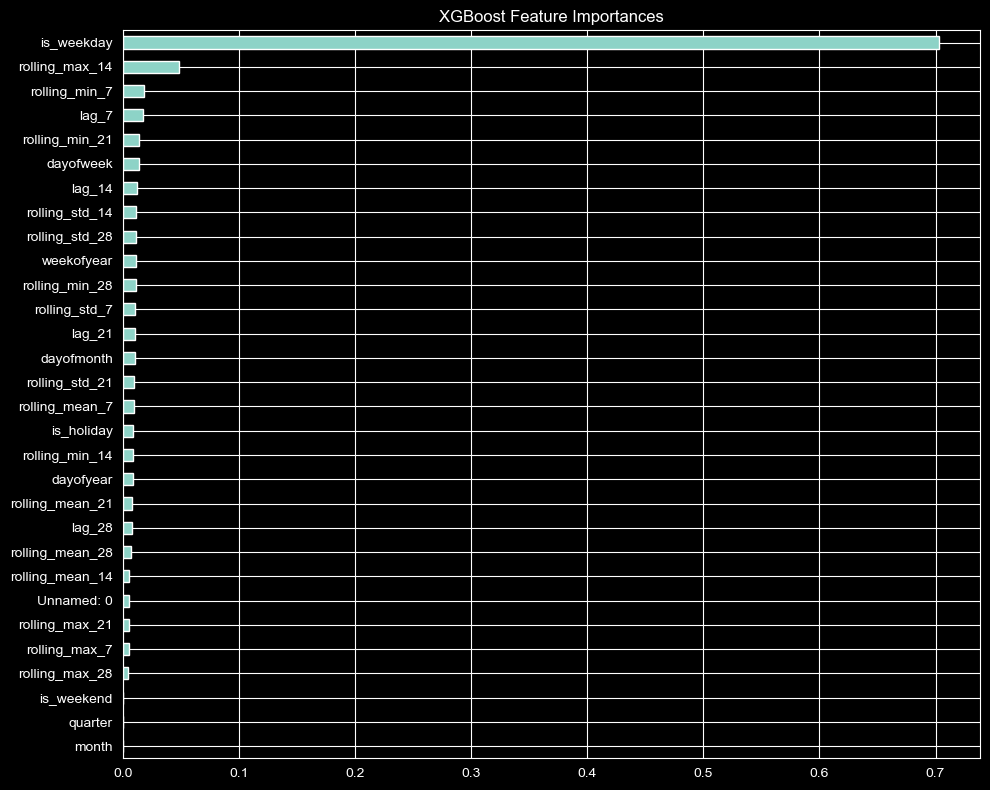

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()